# Mall Customer Segementation

### Load Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Data Understanding

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique()[:10])


CustomerID
[ 1  2  3  4  5  6  7  8  9 10]

Genre
['Male' 'Female']

Age
[19 21 20 23 31 22 35 64 30 67]

Annual Income (k$)
[15 16 17 18 19 20 21 23 24 25]

Spending Score (1-100)
[39 81  6 77 40 76 94  3 72 14]


### EDA

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

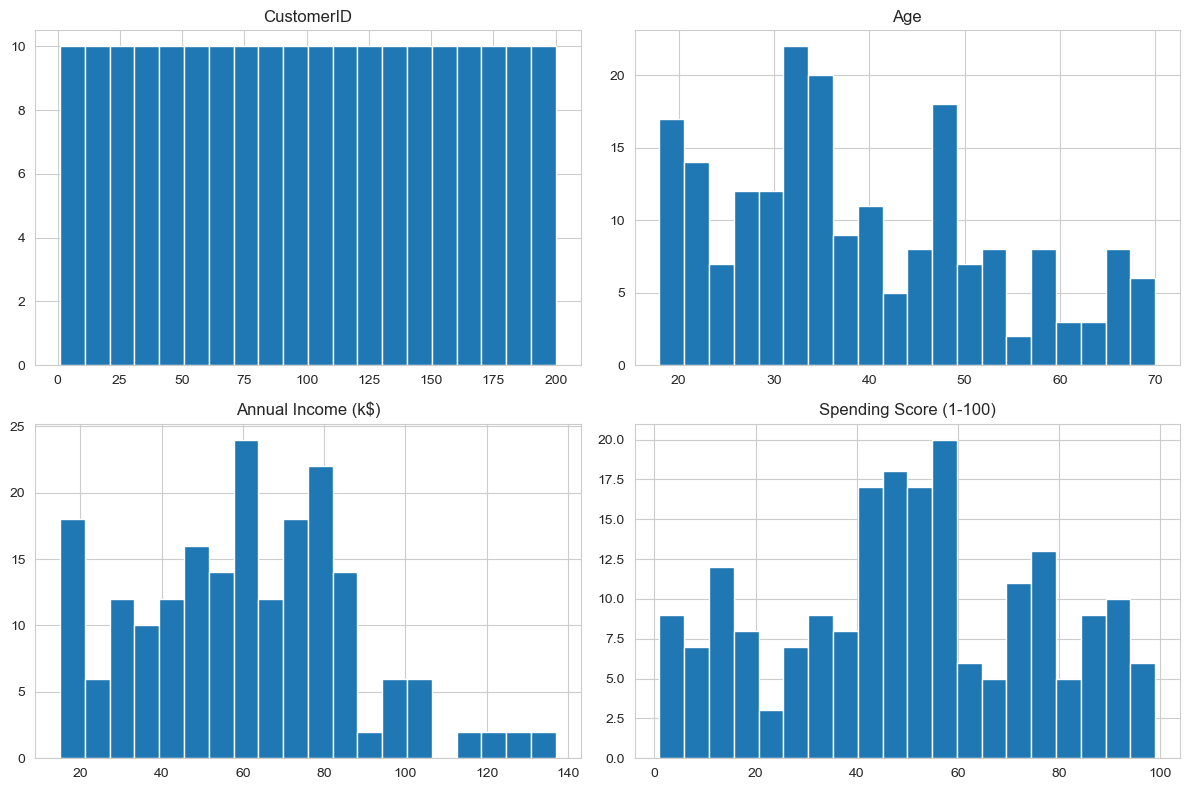

In [11]:
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

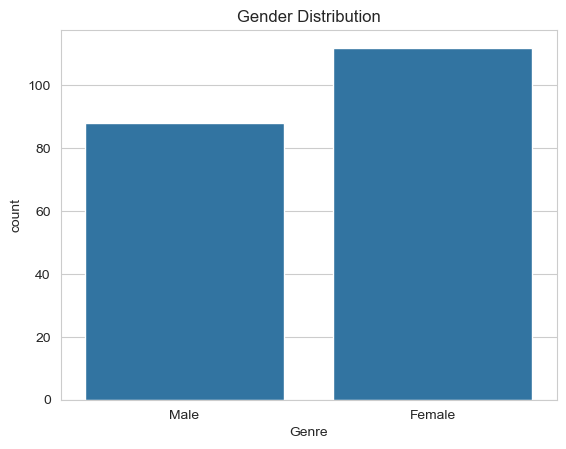

In [13]:
sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

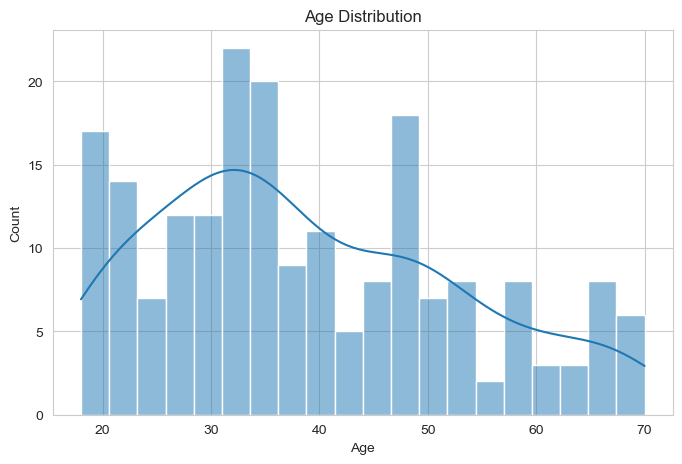

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

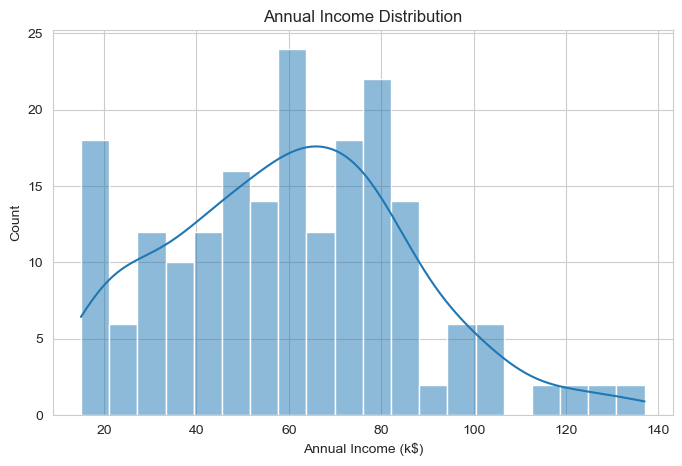

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

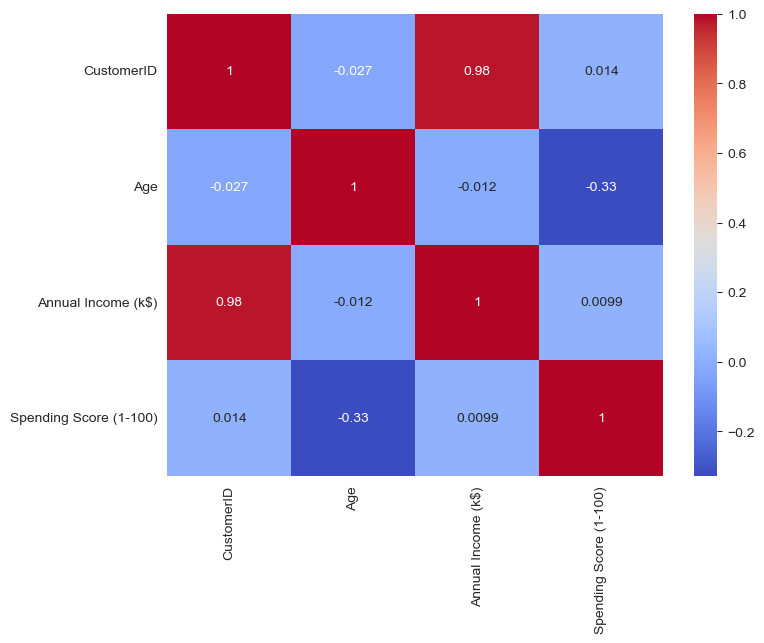

In [16]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

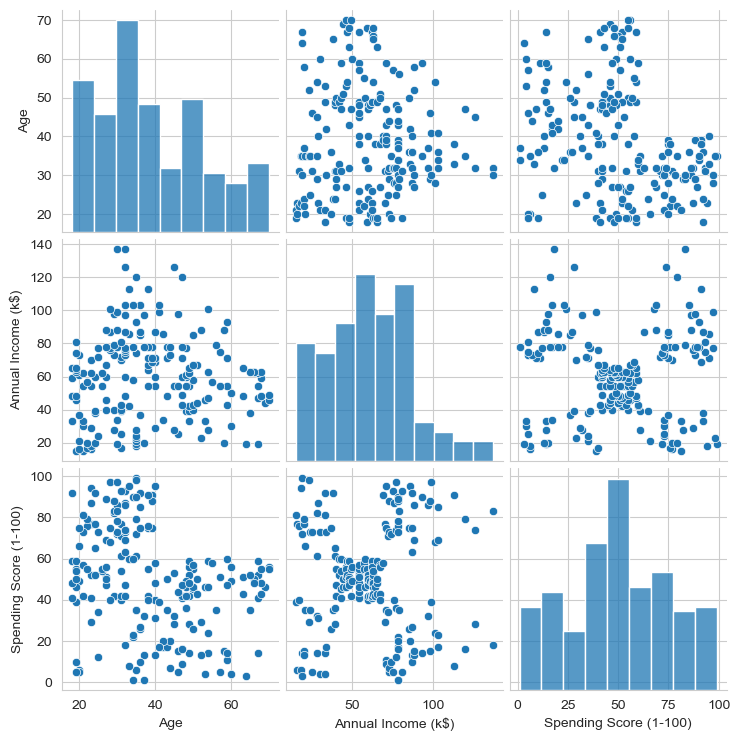

In [17]:
sns.pairplot(
    df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]
)
plt.show()

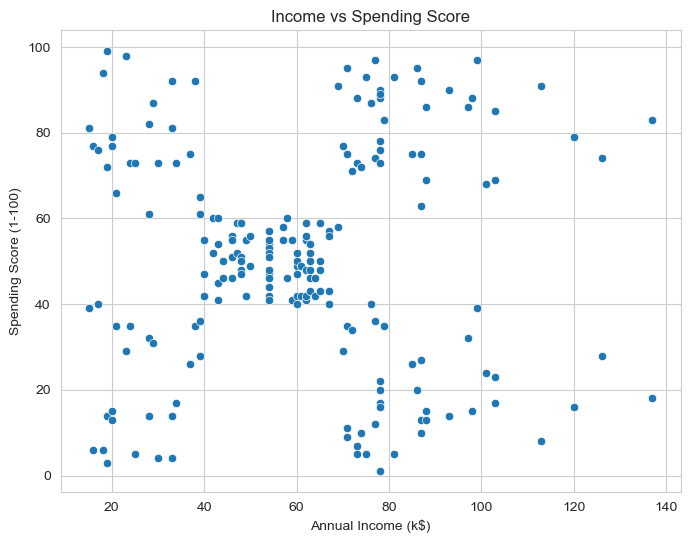

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")
plt.show()

In [28]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL*"
)

### Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


### Elbow Method

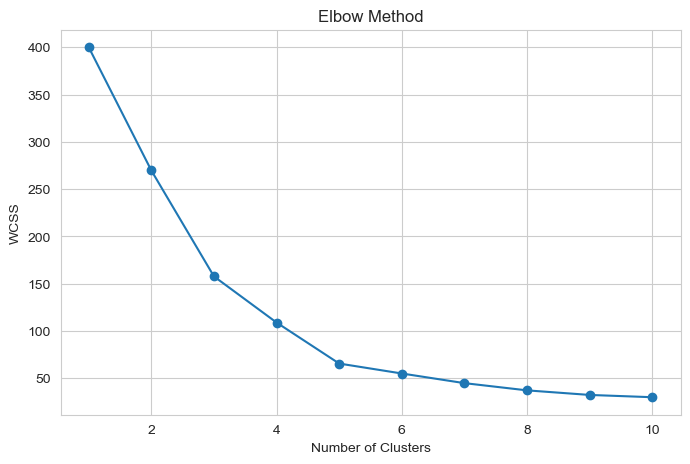

In [30]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Silhoutte Score

In [31]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}  Silhouette Score={score:.3f}")

K=2  Silhouette Score=0.321
K=3  Silhouette Score=0.467
K=4  Silhouette Score=0.494
K=5  Silhouette Score=0.555
K=6  Silhouette Score=0.540
K=7  Silhouette Score=0.528
K=8  Silhouette Score=0.455
K=9  Silhouette Score=0.457
K=10  Silhouette Score=0.443


### K-Means Clustering

In [48]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,HC_Cluster,DBSCAN_Cluster
0,1,Male,19,15,39,4,4,0
1,2,Male,21,15,81,2,3,0
2,3,Female,20,16,6,4,4,0
3,4,Female,23,16,77,2,3,0
4,5,Female,31,17,40,4,4,0
5,6,Female,22,17,76,2,3,0
6,7,Female,35,18,6,4,4,0
7,8,Female,23,18,94,2,3,0
8,9,Male,64,19,3,4,4,0
9,10,Female,30,19,72,2,3,0


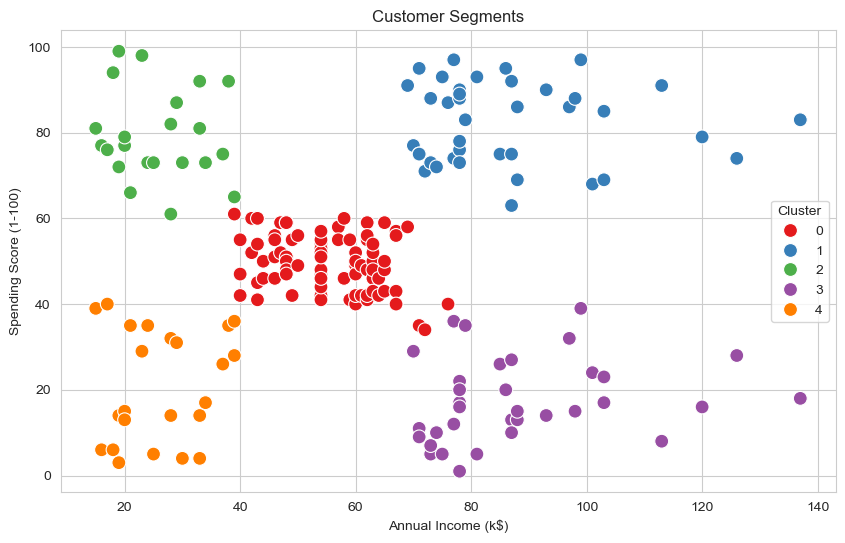

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segments")
plt.show()

In [34]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

print(centers_df)

   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


### Hirarchical Clustering

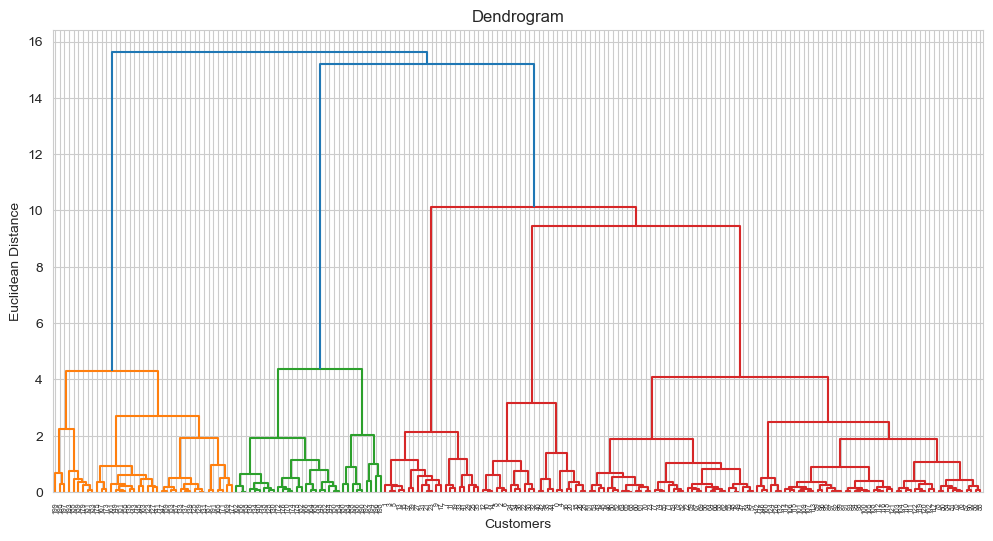

In [35]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12,6))

sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

### Agglomerative Clustering

In [36]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

hc_labels = hc.fit_predict(X_scaled)

df['HC_Cluster'] = hc_labels

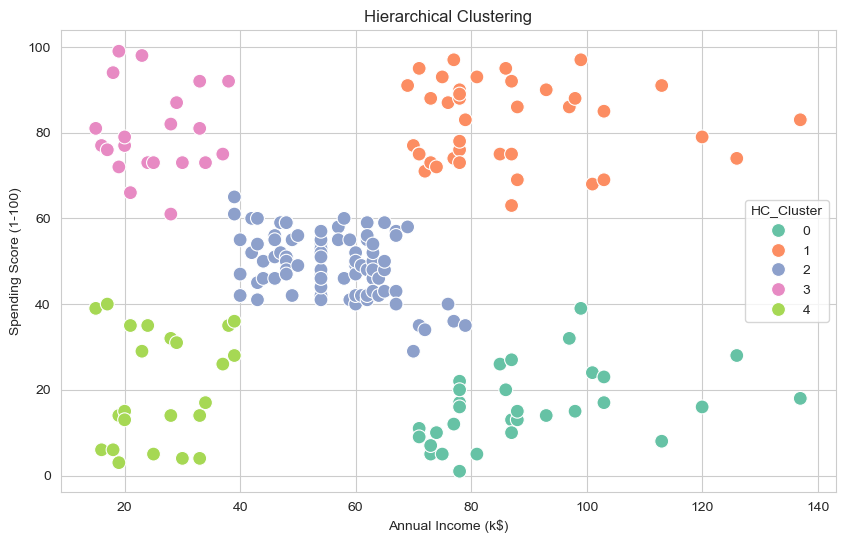

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='HC_Cluster',
    palette='Set2',
    data=df,
    s=100
)

plt.title("Hierarchical Clustering")

plt.show()

## Compare KMeans and HC

,Model,Silhouette Score
0,KMeans,0.554657
1,Hierarchical,0.553809


# DBSCAN

In [41]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_labels

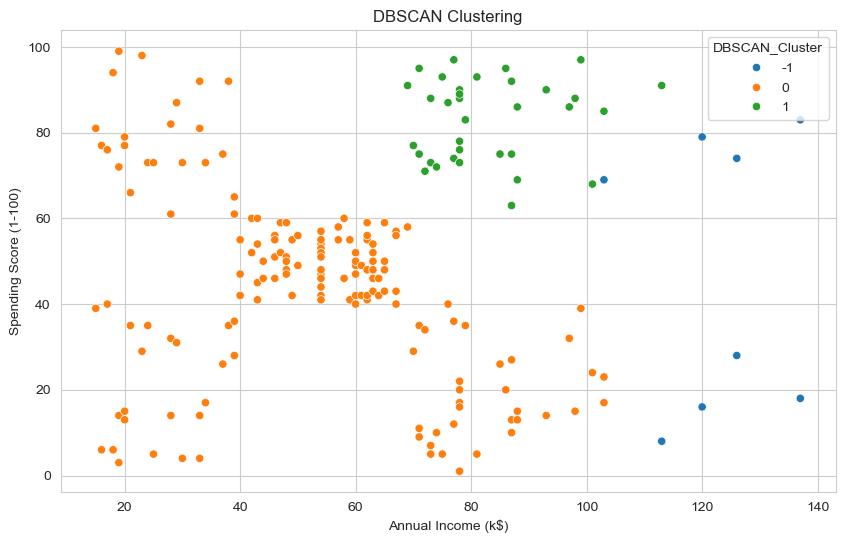

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    data=df,
    palette='tab10'
)

plt.title("DBSCAN Clustering")

plt.show()

## PCA

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(200, 2)

In [51]:
print(pca.explained_variance_ratio_)

[0.50495142 0.49504858]


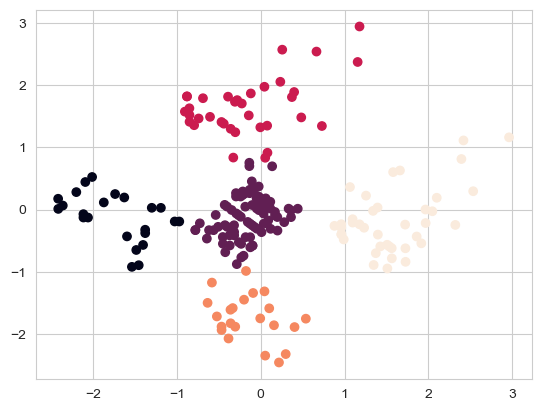

In [52]:
kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(X_pca)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)